<a href="https://colab.research.google.com/github/sajivjose174/Hateful-Memes-Multimodal-Classification/blob/main/Facebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [3]:
import seaborn as sns
import numpy as np
import pandas as pd

In [4]:
#!pip install -q kaggle

In [4]:
!kaggle datasets files -d parthplc/facebook-hateful-meme-dataset

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U4472R0-86QtPgnd7Sr4pHPp26vLxv5UtzMRrvjJlHLOkArC1pTHkMReMRwApmyhe2krb0SLTVyzD0hyqZ60jSlZ_phLavokeiD4NjEdbl4_l7LhS63cqAO
name                  size  creationDate                
------------------  ------  --------------------------  
data/LICENSE.txt      9867  2020-06-14 15:27:50.877000  
data/README.md        3008  2020-06-14 15:27:18.895000  
data/dev.jsonl       55143  2020-06-14 15:27:18.940000  
data/img/01235.png  190492  2020-06-14 15:27:27.761000  
data/img/01236.png  621954  2020-06-14 15:27:42.661000  
data/img/01243.png  586028  2020-06-14 15:27:35.317000  
data/img/01245.png  401283  2020-06-14 15:27:20.250000  
data/img/01247.png  100659  2020-06-14 15:27:43.829000  
data/img/01256.png  417430  2020-06-14 15:27:49.706000  
data/img/01258.png  296836  2020-06-14 15:27:46.975000  
data/img/01264.png  417142  2020-06-14 15:27:19.104000  
data/img/01268.png  162692  2020-06-14 15:27:33.239000  
data/img/01269.png  150072  2020-06-14 

In [5]:
!kaggle datasets download -d parthplc/facebook-hateful-meme-dataset

Dataset URL: https://www.kaggle.com/datasets/parthplc/facebook-hateful-meme-dataset
License(s): unknown
100% 3.35G/3.35G [02:13<00:00, 27.1MB/s]



In [6]:
import os

os.listdir('/content')

['.config', 'facebook-hateful-meme-dataset.zip', 'sample_data']

In [7]:
import zipfile

zip_path = '/content/facebook-hateful-meme-dataset.zip'
extract_path = '/content/hateful_memes_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
import os

os.listdir('/content/hateful_memes_dataset')

['data']

In [9]:
import os

os.listdir('/content/hateful_memes_dataset/data')

['train.jsonl', 'LICENSE.txt', 'README.md', 'test.jsonl', 'dev.jsonl', 'img']

In [10]:
import json

train_path = '/content/hateful_memes_dataset/data/train.jsonl'

with open(train_path, 'r') as f:
    first_line = f.readline()

print(first_line)

{"id":42953,"img":"img\/42953.png","label":0,"text":"its their character not their color that matters"}



##Exploratory Data Analysis:

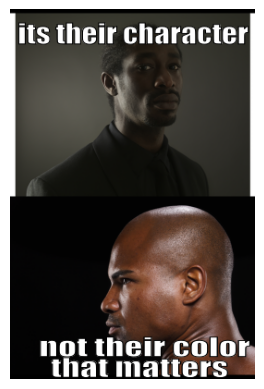

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = '/content/hateful_memes_dataset/data/img/42953.png'

image = Image.open(img_path)

plt.imshow(image)
plt.axis('off')
plt.show()

In [12]:
import json
from collections import Counter

train_path = '/content/hateful_memes_dataset/data/train.jsonl'

labels = []

with open(train_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        labels.append(data['label'])

print(Counter(labels))

Counter({0: 5450, 1: 3050})


<Axes: >

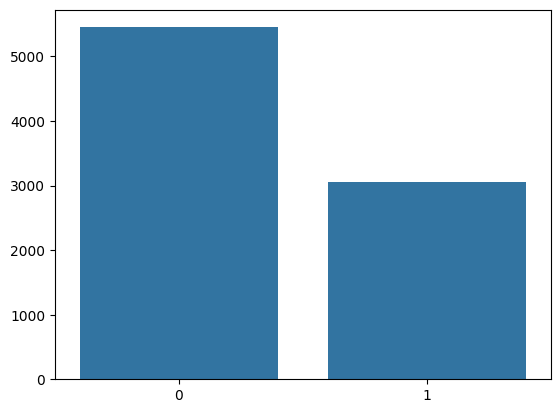

In [13]:
train_path = '/content/hateful_memes_dataset/data/train.jsonl'

labels = []

with open(train_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        labels.append(data['label'])
sns.barplot(Counter(labels))

##Visual Only Model (ResNet50):

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

In [15]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg")

base_model.trainable = False
print(base_model.output_shape)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(None, 2048)


In [16]:
from tensorflow.keras.utils import load_img, img_to_array

img_path = '/content/hateful_memes_dataset/data/img/42953.png'

image = load_img(
    img_path,
    target_size=(224, 224))
image_array = img_to_array(image)

print(image_array.shape)

(224, 224, 3)


In [17]:
image_batch = np.expand_dims(image_array, axis=0)

print(image_batch.shape)

(1, 224, 224, 3)


In [18]:
from tensorflow.keras.applications.resnet50 import preprocess_input

image_batch = preprocess_input(image_batch)

In [19]:
features=base_model(image_batch)
print(features)

tf.Tensor([[0.27282184 0.02072623 0.         ... 0.10004244 0.0142238  0.46074432]], shape=(1, 2048), dtype=float32)


In [20]:
train_path = '/content/hateful_memes_dataset/data/train.jsonl'

In [21]:
import pandas as pd

train_df = pd.read_json(train_path, lines=True)

train_df.head()

,id,img,label,text
0,42953,img/42953.png,0,its their character not their color that matters
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...
2,13894,img/13894.png,0,putting bows on your pet
3,37408,img/37408.png,0,i love everything and everybody! except for sq...
4,82403,img/82403.png,0,"everybody loves chocolate chip cookies, even h..."


In [22]:
print(train_df.shape)

(8500, 4)


In [23]:
train_df['label'].value_counts()

,count
label,
0,5450
1,3050


In [24]:
image_dir = '/content/hateful_memes_dataset/data'

train_df['img_path'] = train_df['img'].apply(
    lambda x: f"{image_dir}/{x}"
)

train_df[['img', 'img_path', 'label']].head()

,img,img_path,label
0,img/42953.png,/content/hateful_memes_dataset/data/img/42953.png,0
1,img/23058.png,/content/hateful_memes_dataset/data/img/23058.png,0
2,img/13894.png,/content/hateful_memes_dataset/data/img/13894.png,0
3,img/37408.png,/content/hateful_memes_dataset/data/img/37408.png,0
4,img/82403.png,/content/hateful_memes_dataset/data/img/82403.png,0


In [25]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

def preprocess_image(img_path):
    image = load_img(
        img_path,
        target_size=(224, 224)
    )

    image = img_to_array(image)
    image = preprocess_input(image)

    return image

In [26]:
##connect the image path and the labels:

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df['img_path'].values, train_df['label'].values))

In [27]:
## load the actual image and pre-process with the connection already done at the above step:

def preprocess_image(img_path, label):
    image = load_img(
        img_path,
        target_size=(224, 224)
    )

    image = img_to_array(image)
    image = preprocess_input(image)

    return image, label

In [28]:
##the real pre-process:

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

def preprocess_image(img_path, label):
    image = tf.io.read_file(img_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = preprocess_input(image)

    return image, label

train_ds = train_ds.map(preprocess_image)

In [29]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg"
)

base_model.trainable = False

In [30]:
from tensorflow.keras import layers

model=tf.keras.Sequential([base_model,
                           layers.Dense(128, activation='relu'),
                           layers.Dropout(0.3),
                           layers.Dense(1, activation='sigmoid')])

In [31]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
#validation dataset:

val_path = '/content/hateful_memes_dataset/data/dev.jsonl'

val_df = pd.read_json(val_path, lines=True)

print(val_df.shape)
val_df.head()

#Create the full image paths
val_df['img_path'] = val_df['img'].apply(
    lambda x: f"{image_dir}/{x}")

# image, label connection:
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df['img_path'].values, val_df['label'].values))

#Image pre-process: ()

val_ds = val_ds.map(preprocess_image)


(500, 4)


In [33]:
##Since it expects (32, 224, 224, 3) where 32 is the batch-size as the input:
train_ds = train_ds.batch(32)
val_ds = val_ds.batch(32)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, checkpoint])

Epoch 1/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 1108s 4s/step - accuracy: 0.6285 - loss: 0.6704 - val_accuracy: 0.4840 - val_loss: 0.6936
Epoch 2/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 1114s 4s/step - accuracy: 0.6386 - loss: 0.6476 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 3/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 1115s 4s/step - accuracy: 0.6518 - loss: 0.6343 - val_accuracy: 0.4940 - val_loss: 0.7010
Epoch 4/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 1114s 4s/step - accuracy: 0.6547 - loss: 0.6269 - val_accuracy: 0.5080 - val_loss: 0.6981


In [35]:
print(train_ds.element_spec)
print(val_ds.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Get predictions
resnet_probabilities = model.predict(val_ds).ravel()

# Convert probabilities to class predictions
resnet_predictions = (resnet_probabilities >= 0.5).astype(int)

# True labels
resnet_true = val_df["label"].values

# Metrics
print("Accuracy:", accuracy_score(resnet_true, resnet_predictions))
print("Precision:", precision_score(resnet_true, resnet_predictions))
print("Recall:", recall_score(resnet_true, resnet_predictions))
print("F1:", f1_score(resnet_true, resnet_predictions))
print("AUROC:", roc_auc_score(resnet_true, resnet_probabilities))

print("\nConfusion Matrix:")
print(confusion_matrix(resnet_true, resnet_predictions))

print("\nClassification Report:")
print(classification_report(resnet_true, resnet_predictions))

16/16 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step
Accuracy: 0.484
Precision: 0.375
Recall: 0.048
F1: 0.0851063829787234
AUROC: 0.529952

Confusion Matrix:
[[230  20]
 [238  12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.92      0.64       250
           1       0.38      0.05      0.09       250

    accuracy                           0.48       500
   macro avg       0.43      0.48      0.36       500
weighted avg       0.43      0.48      0.36       500



##Text Only Model (BERT):


In [37]:
##bert (AutoTokenizer automatically loads the appropriate tokenizer for that checkpoint — in this case, BERT's WordPiece tokenizer.)
##The tokenizer must match the pretrained model.

#!pip install --force-reinstall -U transformers

from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

bert = AutoModel.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
train_df

,id,img,label,text,img_path
0,42953,img/42953.png,0,its their character not their color that matters,/content/hateful_memes_dataset/data/img/42953.png
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...,/content/hateful_memes_dataset/data/img/23058.png
2,13894,img/13894.png,0,putting bows on your pet,/content/hateful_memes_dataset/data/img/13894.png
3,37408,img/37408.png,0,i love everything and everybody! except for sq...,/content/hateful_memes_dataset/data/img/37408.png
4,82403,img/82403.png,0,"everybody loves chocolate chip cookies, even h...",/content/hateful_memes_dataset/data/img/82403.png
...,...,...,...,...,...
8495,10423,img/10423.png,1,nobody wants to hang auschwitz me,/content/hateful_memes_dataset/data/img/10423.png
8496,98203,img/98203.png,1,when god grants you a child after 20 years of ...,/content/hateful_memes_dataset/data/img/98203.png
8497,36947,img/36947.png,1,gays on social media: equality! body positivit...,/content/hateful_memes_dataset/data/img/36947.png
8498,16492,img/16492.png,1,having a bad day? you could be a siamese twin ...,/content/hateful_memes_dataset/data/img/16492.png


In [39]:
text = train_df['text'].iloc[0]

print(text)

its their character not their color that matters


In [40]:
tokens=tokenizer(text,padding='max_length',truncation=True,max_length=128,return_tensors='pt')

In [41]:
print(tokens.keys())
print(tokens['input_ids'].shape)
print(tokens['attention_mask'].shape)

KeysView({'input_ids': tensor([[ 101, 2049, 2037, 2839, 2025, 2037, 3609, 2008, 5609,  102,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        

In [42]:
##creating a class for pytorch to create the id, id-label pairing:
from torch.utils.data import Dataset, DataLoader
import torch

class MemeDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length=128):                  #####what all are getting passed.
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):                                                            ###Length of the examples.
        return len(self.texts)

    def __getitem__(self, idx):                                                   ### take the text and label.
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )                                                                           ###encoding

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [43]:
train_text_dataset = MemeDataset(
    train_df['text'].values,
    train_df['label'].values,
    tokenizer)

val_text_dataset = MemeDataset(
    val_df['text'].values,
    val_df['label'].values,
    tokenizer)

In [44]:
###this is to create batch.


train_loader = DataLoader(
    train_text_dataset,
    batch_size=16,
    shuffle=True)

val_loader = DataLoader(
    val_text_dataset,
    batch_size=16,
    shuffle=False)

In [45]:
import torch
import torch.nn as nn

# -----------------------------
# BERT CLASSIFIER
# -----------------------------

class BertClassifier(nn.Module):     #### <<<<---------------[CLS] embedding (768)

    def __init__(self, bert):
        super().__init__()

        self.bert = bert
        self.classifier = nn.Linear(768, 1)     #### <<<<<-----BERt has a hidden shape of 768 so thats why we take the linear layer with 768 dimensions.

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]

        logits = self.classifier(cls_embedding)

        return logits


# -----------------------------
# MODEL
# -----------------------------

model = BertClassifier(bert)


# -----------------------------
# LOSS & OPTIMIZER
# -----------------------------

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)


# -----------------------------
# DEVICE
# -----------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)


# -----------------------------
# TRAINING
# -----------------------------

epochs = 3

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].float().to(device)

        # Forward pass
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).squeeze(1)

        # Calculate loss
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/3 - Loss: 0.5796
Epoch 2/3 - Loss: 0.4956
Epoch 3/3 - Loss: 0.4194


In [46]:
###this is liek our oredict on validation data without updating the weights.


import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Forward pass
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).squeeze(1)

        # Convert logits → probabilities
        probs = torch.sigmoid(logits)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


# Convert probabilities to predictions
all_preds = [1 if p >= 0.5 else 0 for p in all_probs]


# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)


print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUROC    : {auroc:.4f}")

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.5500
Precision: 0.6289
Recall   : 0.2440
F1 Score : 0.3516
AUROC    : 0.6429

Confusion Matrix:
[[214  36]
 [189  61]]


##MultiModal (Resnet50 + Bert) Using Pytorch:

In [47]:
## To extract features from resnet by passing batches of images with pre-process.

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

def extract_resnet_features(df, batch_size=32):

    all_features = []

    for start in range(0, len(df), batch_size):

        batch_paths = df["img_path"].values[start:start + batch_size]

        images = []

        for img_path in batch_paths:

            image = tf.io.read_file(img_path)
            image = tf.image.decode_png(image, channels=3)
            image = tf.image.resize(image, (224, 224))

            images.append(image)

        # Convert the list of images into one batch
        images = tf.stack(images)

        # ResNet preprocessing
        images = preprocess_input(images)

        # Extract features for the entire batch
        features = base_model(
            images,
            training=False)        ##Training= false because we need jus the vectors.

        all_features.append(features.numpy())

        print(
            f"Processed {min(start + batch_size, len(df))}/{len(df)}"
        )

    return np.concatenate(all_features, axis=0)     ##concat one below the other

In [48]:
train_image_features = extract_resnet_features(train_df)

print(train_image_features.shape)

Processed 32/8500
Processed 64/8500
Processed 96/8500
Processed 128/8500
Processed 160/8500
Processed 192/8500
Processed 224/8500
Processed 256/8500
Processed 288/8500
Processed 320/8500
Processed 352/8500
Processed 384/8500
Processed 416/8500
Processed 448/8500
Processed 480/8500
Processed 512/8500
Processed 544/8500
Processed 576/8500
Processed 608/8500
Processed 640/8500
Processed 672/8500
Processed 704/8500
Processed 736/8500
Processed 768/8500
Processed 800/8500
Processed 832/8500
Processed 864/8500
Processed 896/8500
Processed 928/8500
Processed 960/8500
Processed 992/8500
Processed 1024/8500
Processed 1056/8500
Processed 1088/8500
Processed 1120/8500
Processed 1152/8500
Processed 1184/8500
Processed 1216/8500
Processed 1248/8500
Processed 1280/8500
Processed 1312/8500
Processed 1344/8500
Processed 1376/8500
Processed 1408/8500
Processed 1440/8500
Processed 1472/8500
Processed 1504/8500
Processed 1536/8500
Processed 1568/8500
Processed 1600/8500
Processed 1632/8500
Processed 1664

In [49]:
val_image_features = extract_resnet_features(val_df)

Processed 32/500
Processed 64/500
Processed 96/500
Processed 128/500
Processed 160/500
Processed 192/500
Processed 224/500
Processed 256/500
Processed 288/500
Processed 320/500
Processed 352/500
Processed 384/500
Processed 416/500
Processed 448/500
Processed 480/500
Processed 500/500


In [50]:
##Step 2:   align image features with their text and labels + tokenize the text.

In [51]:
from torch.utils.data import Dataset, DataLoader
import torch

class MultimodalDataset(Dataset):

    def __init__(
        self,
        texts,
        image_features,
        labels,
        tokenizer,
        max_length=128
    ):
        self.texts = texts
        self.image_features = image_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )




        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),

            "image_features": torch.tensor(
                self.image_features[idx],
                dtype=torch.float32
            ),

            "label": torch.tensor(
                self.labels[idx],
                dtype=torch.float32) }

In [52]:
train_multimodal_dataset = MultimodalDataset(
    train_df["text"].values,
    train_image_features,
    train_df["label"].values,
    tokenizer
)

val_multimodal_dataset = MultimodalDataset(
    val_df["text"].values,
    val_image_features,
    val_df["label"].values,
    tokenizer
)

In [53]:
##DataLoader makes batches like batch_sieze

train_multimodal_loader = DataLoader(
    train_multimodal_dataset,
    batch_size=16,
    shuffle=True
)

val_multimodal_loader = DataLoader(
    val_multimodal_dataset,
    batch_size=16,
    shuffle=False
)

batch = next(iter(train_multimodal_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["image_features"].shape)
print(batch["label"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 2048])
torch.Size([16])


In [54]:
##Step 3: BERT's 768 features and ResNet's 2048 features become one 2816-dimensional representation.

In [55]:
class MultimodalClassifier(nn.Module):

    def __init__(self, bert):
        super().__init__()

        self.bert = bert

        self.classifier = nn.Sequential(
            nn.Linear(2816, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1))              ### this is where the classification code happens.

    def forward(self, input_ids, attention_mask, image_features):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]

        combined = torch.cat(
            [cls_embedding, image_features],
            dim=1)                                                       ####This combines the vectors to the resultant vecotr.

        logits = self.classifier(combined)

        return logits

In [56]:
multimodal_model = MultimodalClassifier(bert)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    multimodal_model.parameters(),
    lr=2e-5
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

multimodal_model = multimodal_model.to(device)

epochs = 3

for epoch in range(epochs):

    multimodal_model.train()

    total_loss = 0

    for batch in train_multimodal_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        image_features = batch["image_features"].to(device)
        labels = batch["label"].to(device)

        logits = multimodal_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image_features=image_features
        ).squeeze(1)

        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_multimodal_loader)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/3 - Loss: 0.3955
Epoch 2/3 - Loss: 0.3120
Epoch 3/3 - Loss: 0.2758


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

multimodal_model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for batch in val_multimodal_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        image_features = batch["image_features"].to(device)
        labels = batch["label"].to(device)

        logits = multimodal_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image_features=image_features
        ).squeeze(1)

        probs = torch.sigmoid(logits)     ###sigmoid converts logits to probs.

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert probabilities into 0/1 predictions
all_preds = [
    1 if p >= 0.5 else 0
    for p in all_probs]

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUROC    : {auroc:.4f}")

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.5680
Precision: 0.6197
Recall   : 0.3520
F1 Score : 0.4490
AUROC    : 0.6108

Confusion Matrix:
[[196  54]
 [162  88]]


##MultiModal (Resnet50 + Bert) Using Keras Version of BERT with RESNET50:

In [58]:
# ============================================================
# KERAS BERT + RESNET MULTIMODAL HATEFUL MEMES CLASSIFIER
# ============================================================

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import tensorflow as tf
import keras
import keras_hub

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. LOAD PRETRAINED BERT BACKBONE + PREPROCESSOR
# ============================================================

bert_backbone = keras_hub.models.BertBackbone.from_preset(
    "bert_base_en_uncased"
)

bert_preprocessor = keras_hub.models.BertPreprocessor.from_preset(
    "bert_base_en_uncased"
)
bert_backbone.trainable = False
print("BERT hidden dimension:", bert_backbone.hidden_dim)


# ============================================================
# 2. PREPROCESS TEXT
# ============================================================

# Raw text → token_ids + padding_mask
train_text_inputs = bert_preprocessor(
    train_df["text"].values
)

val_text_inputs = bert_preprocessor(
    val_df["text"].values
)


# ============================================================
# 3. DEFINE MODEL INPUTS
# ============================================================

input_ids = keras.Input(
    shape=(None,),
    dtype="int32",
    name="token_ids"
)

segment_ids = keras.Input(
    shape=(None,),
    dtype="int32",
    name="segment_ids"
)

padding_mask = keras.Input(
    shape=(None,),
    dtype="int32",
    name="padding_mask"
)

image_features = keras.Input(
    shape=(2048,),
    dtype="float32",
    name="image_features"
)


# ============================================================
# 4. BERT BACKBONE
# ============================================================

bert_outputs = bert_backbone({
    "token_ids": input_ids,
    "segment_ids": segment_ids,
    "padding_mask": padding_mask
})

# BERT output:
# (batch_size, sequence_length, 768)
sequence_output = bert_outputs["sequence_output"]

# Take the [CLS] token representation
cls_embedding = sequence_output[:, 0, :]

# CLS representation:
# (batch_size, 768)


# ============================================================
# 5. MULTIMODAL FUSION
# ============================================================

combined_features = keras.layers.Concatenate(
    axis=1
)([
    cls_embedding,
    image_features
])

# 768 + 2048 = 2816


# ============================================================
# 6. CLASSIFICATION HEAD
# ============================================================

x = keras.layers.Dense(
    256,
    activation="relu"
)(combined_features)

x = keras.layers.Dropout(0.3)(x)

output = keras.layers.Dense(
    1
)(x)


# ============================================================
# 7. BUILD MODEL
# ============================================================
##Sequential API:
multimodal_model = keras.Model(
    inputs={
        "token_ids": input_ids,
        "padding_mask": padding_mask,
        "segment_ids": segment_ids,
        "image_features": image_features
    },
    outputs=output
)


# ============================================================
# 8. COMPILE
# ============================================================

multimodal_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=2e-5
    ),
    loss=keras.losses.BinaryCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)


# ============================================================
# 9. DISPLAY MODEL
# ============================================================

multimodal_model.summary()


# ============================================================
# 10. TRAIN
# ============================================================

history = multimodal_model.fit(
    {
    "token_ids": train_text_inputs["token_ids"],
    "segment_ids": train_text_inputs["segment_ids"],
    "padding_mask": train_text_inputs["padding_mask"],
    "image_features": train_image_features
    },

    train_df["label"].values,

    validation_data=(
    {
    "token_ids": val_text_inputs["token_ids"],
    "segment_ids": val_text_inputs["segment_ids"],
    "padding_mask": val_text_inputs["padding_mask"],
    "image_features": val_image_features
    },

        val_df["label"].values
    ),

    batch_size=16,
    epochs=3
)


# ============================================================
# 11. VALIDATION PREDICTIONS
# ============================================================

logits = multimodal_model.predict(
    {
        "token_ids": val_text_inputs["token_ids"],
        "padding_mask": val_text_inputs["padding_mask"],
        "segment_ids": val_text_inputs["segment_ids"],
        "image_features": val_image_features
    },
    batch_size=16
).squeeze()


# ============================================================
# 12. CONVERT LOGITS → PROBABILITIES
# ============================================================

probabilities = tf.sigmoid(logits).numpy()


# ============================================================
# 13. CONVERT PROBABILITIES → 0/1 PREDICTIONS
# ============================================================

predictions = (
    probabilities >= 0.5
).astype(int)


# ============================================================
# 14. METRICS
# ============================================================

labels = val_df["label"].values

accuracy = accuracy_score(
    labels,
    predictions
)

precision = precision_score(
    labels,
    predictions
)

recall = recall_score(
    labels,
    predictions
)

f1 = f1_score(
    labels,
    predictions
)

auroc = roc_auc_score(
    labels,
    probabilities
)

cm = confusion_matrix(
    labels,
    predictions
)


# ============================================================
# 15. RESULTS
# ============================================================

print("\n==============================")
print("MULTIMODAL MODEL RESULTS")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUROC    : {auroc:.4f}")

print("\nConfusion Matrix:")
print(cm)

BERT hidden dimension: 768


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 109,482,2… │ padding_mask[0][… │
│ (BertBackbone)      │ (None, None,      │            │ segment_ids[0][0… │
│                     │ 768)]             │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 768)       │          0 │ bert_backbone[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2816)      │          0 │ get_item_1[0][0], │
│ (Concatenate)       │                   │            │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    721,152 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 256)       │          0 │ dense_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_37[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 110,203,649 (420.39 MB)

 Trainable params: 721,409 (2.75 MB)

 Non-trainable params: 109,482,240 (417.64 MB)

Epoch 1/3
532/532 ━━━━━━━━━━━━━━━━━━━━ 394s 666ms/step - accuracy: 0.6268 - loss: 0.7005 - val_accuracy: 0.5100 - val_loss: 0.7746
Epoch 2/3
532/532 ━━━━━━━━━━━━━━━━━━━━ 322s 606ms/step - accuracy: 0.6551 - loss: 0.6313 - val_accuracy: 0.5240 - val_loss: 0.7219
Epoch 3/3
532/532 ━━━━━━━━━━━━━━━━━━━━ 322s 605ms/step - accuracy: 0.6691 - loss: 0.6047 - val_accuracy: 0.5100 - val_loss: 0.7962
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 656ms/step

MULTIMODAL MODEL RESULTS
Accuracy : 0.5400
Precision: 0.7174
Recall   : 0.1320
F1 Score : 0.2230
AUROC    : 0.5610

Confusion Matrix:
[[237  13]
 [217  33]]


In [59]:
print(type(bert_outputs))
print(bert_outputs.keys())

<class 'dict'>
dict_keys(['sequence_output', 'pooled_output'])


##Clip Model:

In [60]:
#CLIP is a vision-language model with two encoders:

In [61]:
!pip install -q transformers

In [62]:
from transformers import CLIPProcessor, CLIPModel

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32")                     #The processor handles the input preparation (prepares image + text for those encoders)

clip = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32")                     #loads the pretrained CLIP model, which contains both encoders.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [63]:
print(type(clip))
print(clip.config.projection_dim)

<class 'transformers.models.clip.modeling_clip.CLIPModel'>
512


In [65]:
import numpy as np
import tensorflow as tf
import keras
import keras_hub
from tensorflow.keras.utils import load_img, img_to_array


# --------------------------------------------------
# Load CLIP
# --------------------------------------------------

clip_preprocessor = keras_hub.models.CLIPPreprocessor.from_preset(
    "clip_vit_base_patch32"
)

clip = keras_hub.models.CLIPBackbone.from_preset(
    "clip_vit_base_patch32"
)

clip.trainable = False

print("CLIP loaded")
print("Projection dimension:", clip.projection_dim)


# --------------------------------------------------
# Load images for ONE batch
# --------------------------------------------------

def load_clip_images(paths):

    images = []

    for path in paths:

        image = load_img(
            path,
            target_size=(224, 224)
        )

        image = img_to_array(image)

        images.append(image)

    return np.array(images, dtype=np.float32)


# --------------------------------------------------
# Extract CLIP features batch-wise
# --------------------------------------------------

def extract_clip_features(df, batch_size=16):

    all_text_embeddings = []
    all_image_embeddings = []

    for start in range(0, len(df), batch_size):

        end = min(start + batch_size, len(df))

        batch_texts = df["text"].values[start:end]
        batch_paths = df["img_path"].values[start:end]

        # Load only this batch of images
        batch_images = load_clip_images(batch_paths)

        # CLIP preprocessing
        batch_inputs = clip_preprocessor({
            "prompts": batch_texts,
            "images": batch_images
        })

        # ------------------------------------------
        # Text encoder
        # ------------------------------------------

        text_features = clip.text_encoder(
            batch_inputs["token_ids"]
        )

        # Take the final text representation
        text_features = text_features[:, -1, :]

        # Project to CLIP shared embedding space
        text_embeddings = clip.text_projection(
            text_features
        )

        # ------------------------------------------
        # Image encoder
        # ------------------------------------------

        image_features = clip.vision_encoder(
            batch_inputs["images"]
        )

        # Take the image representation
        image_features = image_features[:, 0, :]

        # Project to CLIP shared embedding space
        image_embeddings = clip.vision_projection(
            image_features
        )

        # ------------------------------------------
        # Store batch
        # ------------------------------------------

        all_text_embeddings.append(
            text_embeddings.numpy()
        )

        all_image_embeddings.append(
            image_embeddings.numpy()
        )

        print(
            f"Processed {end}/{len(df)}"
        )

    # Combine all batches
    text_embeddings = np.concatenate(
        all_text_embeddings,
        axis=0
    )

    image_embeddings = np.concatenate(
        all_image_embeddings,
        axis=0
    )

    return text_embeddings, image_embeddings


# --------------------------------------------------
# Extract train features
# --------------------------------------------------

train_text_embeddings, train_image_embeddings = (
    extract_clip_features(
        train_df,
        batch_size=16
    )
)


# --------------------------------------------------
# Extract validation features
# --------------------------------------------------

val_text_embeddings, val_image_embeddings = (
    extract_clip_features(
        val_df,
        batch_size=16
    )
)


# --------------------------------------------------
# Check shapes
# --------------------------------------------------

print("Train text:", train_text_embeddings.shape)
print("Train image:", train_image_embeddings.shape)

print("Val text:", val_text_embeddings.shape)
print("Val image:", val_image_embeddings.shape)

CLIP loaded
Projection dimension: 512


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'token_ids': 'token_ids'}
Received: inputs=Tensor(shape=(16, 77))
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


Processed 16/8500
Processed 32/8500
Processed 48/8500
Processed 64/8500
Processed 80/8500
Processed 96/8500
Processed 112/8500
Processed 128/8500
Processed 144/8500
Processed 160/8500
Processed 176/8500
Processed 192/8500
Processed 208/8500
Processed 224/8500
Processed 240/8500
Processed 256/8500
Processed 272/8500
Processed 288/8500
Processed 304/8500
Processed 320/8500
Processed 336/8500
Processed 352/8500
Processed 368/8500
Processed 384/8500
Processed 400/8500
Processed 416/8500
Processed 432/8500
Processed 448/8500
Processed 464/8500
Processed 480/8500
Processed 496/8500
Processed 512/8500
Processed 528/8500
Processed 544/8500
Processed 560/8500
Processed 576/8500
Processed 592/8500
Processed 608/8500
Processed 624/8500
Processed 640/8500
Processed 656/8500
Processed 672/8500
Processed 688/8500
Processed 704/8500
Processed 720/8500
Processed 736/8500
Processed 752/8500
Processed 768/8500
Processed 784/8500
Processed 800/8500
Processed 816/8500
Processed 832/8500
Processed 848/8500

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'token_ids': 'token_ids'}
Received: inputs=Tensor(shape=(4, 77))
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(4, 224, 224, 3))
  warnings.warn(msg)


Processed 8500/8500
Processed 16/500
Processed 32/500
Processed 48/500
Processed 64/500
Processed 80/500
Processed 96/500
Processed 112/500
Processed 128/500
Processed 144/500
Processed 160/500
Processed 176/500
Processed 192/500
Processed 208/500
Processed 224/500
Processed 240/500
Processed 256/500
Processed 272/500
Processed 288/500
Processed 304/500
Processed 320/500
Processed 336/500
Processed 352/500
Processed 368/500
Processed 384/500
Processed 400/500
Processed 416/500
Processed 432/500
Processed 448/500
Processed 464/500
Processed 480/500
Processed 496/500
Processed 500/500
Train text: (8500, 512)
Train image: (8500, 512)
Val text: (500, 512)
Val image: (500, 512)


In [66]:
# ============================================================
# CLIP CLASSIFIER — TRAINING + EVALUATION
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# 1. Combine CLIP text + image embeddings
# ------------------------------------------------------------

train_clip_features = np.concatenate(
    [train_text_embeddings, train_image_embeddings],
    axis=1
)

val_clip_features = np.concatenate(
    [val_text_embeddings, val_image_embeddings],
    axis=1
)

print("Train CLIP features:", train_clip_features.shape)
print("Val CLIP features:", val_clip_features.shape)


# ------------------------------------------------------------
# 2. Labels
# ------------------------------------------------------------

y_train = train_df["label"].values
y_val = val_df["label"].values

print("Train labels:", y_train.shape)
print("Val labels:", y_val.shape)


# ------------------------------------------------------------
# 3. Build classifier
# ------------------------------------------------------------

classifier = keras.Sequential([
    keras.layers.Input(shape=(1024,)),

    keras.layers.Dense(
        256,
        activation="relu"
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(1)
])


# ------------------------------------------------------------
# 4. Compile
# ------------------------------------------------------------

classifier.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=keras.losses.BinaryCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)


classifier.summary()


# ------------------------------------------------------------
# 5. Train
# ------------------------------------------------------------

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = classifier.fit(
    train_clip_features,
    y_train,

    validation_data=(
        val_clip_features,
        y_val
    ),

    epochs=10,
    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)


# ------------------------------------------------------------
# 6. Get predictions
# ------------------------------------------------------------

# Model outputs logits because the final layer has no sigmoid
val_logits = classifier.predict(
    val_clip_features,
    verbose=0
).ravel()

# Convert logits → probabilities
val_probabilities = tf.sigmoid(
    val_logits
).numpy()

# Probability threshold = 0.5
y_pred = (
    val_probabilities >= 0.5
).astype(int)


# ------------------------------------------------------------
# 7. Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_val,
    y_pred,
    zero_division=0
)

auroc = roc_auc_score(
    y_val,
    val_probabilities
)


# ------------------------------------------------------------
# 8. Print metrics
# ------------------------------------------------------------

print("\n" + "=" * 50)
print("CLIP MULTIMODAL RESULTS")
print("=" * 50)

print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")
print(f"AUROC    :  {auroc:.4f}")


# ------------------------------------------------------------
# 9. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_val,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# 10. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        y_pred,
        target_names=[
            "Not Hateful",
            "Hateful"
        ],
        zero_division=0
    )
)

Train CLIP features: (8500, 1024)
Val CLIP features: (500, 1024)
Train labels: (8500,)
Val labels: (500,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,657 (1.00 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6640 - loss: 0.6029 - val_accuracy: 0.5260 - val_loss: 0.7213
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7071 - loss: 0.5441 - val_accuracy: 0.5280 - val_loss: 0.7323
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7247 - loss: 0.5155 - val_accuracy: 0.5260 - val_loss: 0.7391

CLIP MULTIMODAL RESULTS
Accuracy :  0.5500
Precision:  0.6374
Recall   :  0.2320
F1 Score :  0.3402
AUROC    :  0.6395

Confusion Matrix:
[[217  33]
 [192  58]]

Classification Report:
              precision    recall  f1-score   support

 Not Hateful       0.53      0.87      0.66       250
     Hateful       0.64      0.23      0.34       250

    accuracy                           0.55       500
   macro avg       0.58      0.55      0.50       500
weighted avg       0.58      0.55      0.50       500



In [67]:
# ------------------------------------------------------------
# Error Analysis DataFrame
# ------------------------------------------------------------

error_df = val_df.copy()

error_df["actual"] = y_val
error_df["probability"] = val_probabilities
error_df["predicted"] = y_pred

# Correct / incorrect
error_df["correct"] = (
    error_df["actual"] == error_df["predicted"]
)

print("Total errors:",
      (~error_df["correct"]).sum())

print("False negatives:",
      ((error_df["actual"] == 1) &
       (error_df["predicted"] == 0)).sum())

print("False positives:",
      ((error_df["actual"] == 0) &
       (error_df["predicted"] == 1)).sum())

Total errors: 225
False negatives: 192
False positives: 33


In [68]:
false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
].sort_values(
    "probability",
    ascending=True
)

false_negatives[
    ["id", "text", "probability", "actual", "predicted"]
].head(10)

,id,text,probability,actual,predicted
200,72061,i like my rice crispy please,0.116901,1,0
60,18945,when you decide to go full gas,0.117671,1,0
156,68409,for the last time im not michelle obama,0.119687,1,0
32,91586,left the kitchen too many times,0.129496,1,0
172,34687,everyone is afraid of dark,0.131008,1,0
155,76921,she probably asked a wrong question,0.134210,1,0
449,67103,still better than mexican,0.135262,1,0
226,80426,a talking ape,0.135973,1,0
272,3519,i'm going home i'm russian,0.138210,1,0
127,56207,we broke up but she said we could still be cou...,0.149952,1,0


In [69]:
false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
].sort_values(
    "probability",
    ascending=False
)

false_positives[
    ["id", "text", "probability", "actual", "predicted"]
].head(10)

,id,text,probability,actual,predicted
263,52104,lebanon: before islam after islam but don't wo...,0.803189,0,1
129,63175,if i was uncircumcised i'd hide candy in my di...,0.720746,0,1
389,41728,i believe they are like racism. just shouldn't...,0.710790,0,1
373,97132,in the muslim world all gay men are well hung,0.681853,0,1
250,46812,goat meat is very popular in islamic countries,0.661908,0,1
362,8451,when you ask a jewish girl for her number and ...,0.652886,0,1
269,49621,"wait, mohammad come back i didn't mean to laug...",0.650769,0,1
482,37692,"""islam is a religion of peace stop criticizing...",0.650049,0,1
365,2364,"a jewish shop owner, wears a kippah or yarmulk...",0.639687,0,1
58,91405,wears rag on her head so her brother husband d...,0.609272,0,1


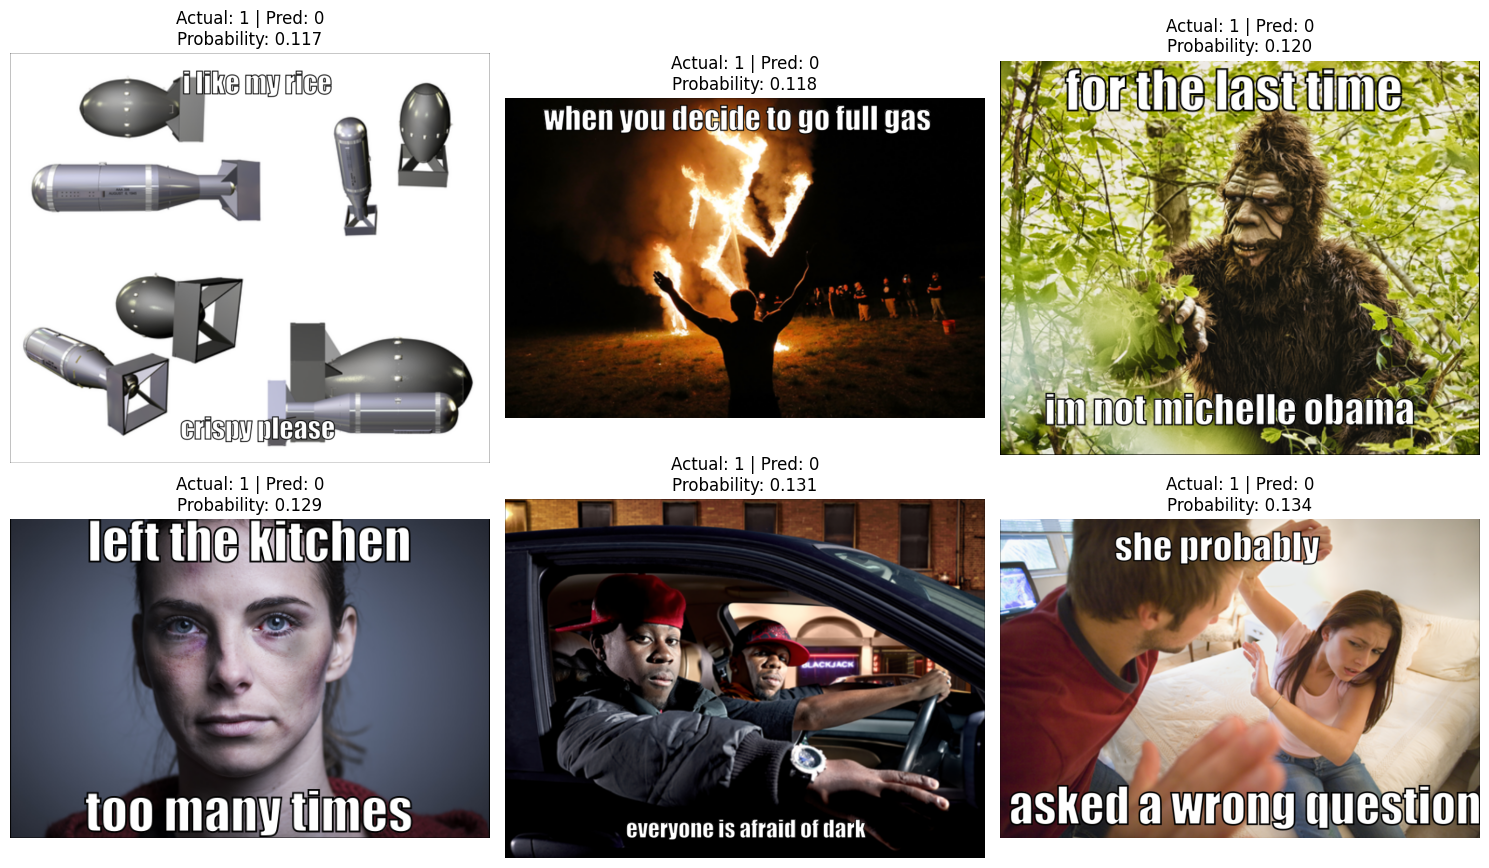

In [70]:
import matplotlib.pyplot as plt
from PIL import Image

samples = false_negatives.head(6)

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

for ax, (_, row) in zip(
    axes.ravel(),
    samples.iterrows()
):

    image = Image.open(row["img_path"])

    ax.imshow(image)
    ax.axis("off")

    ax.set_title(
        f"Actual: {row['actual']} | "
        f"Pred: {row['predicted']}\n"
        f"Probability: {row['probability']:.3f}"
    )

plt.tight_layout()
plt.show()